In [1]:
import argparse
import os

import pandas as pd
import pickle
from tqdm import tqdm
from copy import deepcopy

import numpy as np
import torch
from torch import optim
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt

import sys

In [24]:
# top r svd
def top_r_svd(A, r):
    V, S, Vt = torch.linalg.svd(A, full_matrices=True)

    Vr = V[:, :r]  
    Sr = S[:r]   
    Vtr = Vt[:r, :]
    return Vr, Sr, Vtr

# norm by dividing the max singular value
def svd_norm(A):
    U, S, V = torch.svd(A)

    S_normalized = S / S.max()
    scale = S.max()

    A_normalized = U @ torch.diag(S_normalized) @ V.t()

    return A_normalized, scale

# norm by UV
def uv_norm(A):
    U, S, V = torch.svd(A)

    A_normalized = U @ V.t()

    return A_normalized

# reverse norm by multipying the max singular value
def svd_norm_reverse(A, scale):
    U, S, V = torch.svd(A)

    S_reverse = S * scale

    A_normalized = U @ torch.diag(S_reverse) @ V.t()

    return A_normalized

In [60]:
mat1 = torch.randn(100, 1)
mat2 = torch.randn(1, 3)
M = mat1 @ mat2

r = mat2.shape[0]
epochs = 300
alpha = 0
p = 0.05
noise = 0.01
dataset = 'random'

print(mat2)

tensor([[ 0.8498, -0.3457, -0.8965]])


norm of M: 13.205787658691406


100%|██████████| 300/300 [00:00<00:00, 476.68it/s, In epoch 299, loss: 3.082)]  


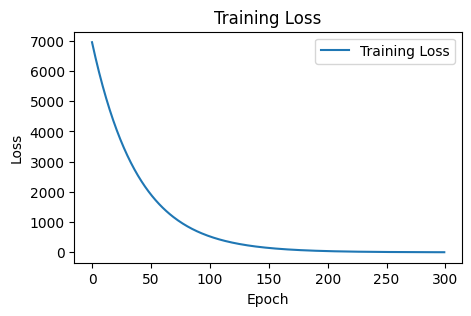

In [74]:
"""
Train for X
"""
# observed M & norm
mask = torch.bernoulli(torch.full((M.shape[0],), p)).bool()
observed_M = deepcopy(M)
observed_M[mask] = 0 # mask user
#observed_M = M
observed_M_norm, scale_M = svd_norm(observed_M) # svd norm
MTM = torch.mm(observed_M_norm.t(), observed_M_norm)
scale_diag = (p-1) / (p**2) * torch.diag(MTM).diag() # objective matrix
A = scale_diag + MTM

print(f"norm of M: {torch.norm(M)}")

# parameters setting
d1, d2 = observed_M.shape
X = torch.randn(d2, d2, requires_grad=True)
loop = tqdm(range(epochs))
eta = 1 / np.sqrt(epochs)
optimizer = optim.SGD([X], lr=eta)

# opt
train_losses = []
writer = SummaryWriter('runs/'+dataset)
for i in loop:
    loss = ((X - A)**2).mean() # mse loss
    U, D, Vt = torch.linalg.svd(X, full_matrices=False)
    loss.backward()

    noise_matrix = torch.normal(mean=0, std=noise, size=(d2, d2))

    X.grad = X.grad + alpha * U @ Vt + noise_matrix # alg
    """
    with torch.no_grad():
        X.data += -eta*X.grad
    """
    optimizer.step()
    X.grad.zero_()
    #print(loss.item())
    writer.add_scalar('Loss', loss.item(), i)
    train_losses.append(loss.item())
    loop.set_postfix_str('In epoch {}, loss: {:.3f})'.format(i, loss.item()))

plt.figure(figsize=(5, 3))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()



In [76]:
"""
normalization for result
"""
X, _ = svd_norm(X)
u, d, vt = torch.linalg.svd(X)
X = vt.t() @ vt
print(f"x - mtm: {X-MTM}")
print(f"norm of X: {torch.norm(X)}")
print(f"norm of M: {torch.norm(MTM)}")


x - mtm: tensor([[ 0.5611,  0.1785,  0.4630],
        [ 0.1785,  0.9274, -0.1884],
        [ 0.4630, -0.1884,  0.5115]], grad_fn=<SubBackward0>)
norm of X: 1.7320507764816284
norm of M: 0.9999998807907104


In the case r=1, use every column to recover M independently. If M can be retrieved, the result should be similar in every column.

In [77]:
"""
recover M
"""
_, S, item_vector = top_r_svd(X, r)
predict_matrix = []
miss_item_u = []
print(M.shape)
for i in range(5):
    M_u = M[i] # get objective row

    print(f"M_u: {M_u}")
    print(f"item_vector: {item_vector}")
    print(f"user_value: {M_u/item_vector}")
    print()



torch.Size([100, 3])
M_u: tensor([ 0.1341, -0.0545, -0.1414])
item_vector: tensor([[0.0000, 0.0986, 0.9951]], grad_fn=<SliceBackward0>)
user_value: tensor([[    inf, -0.5529, -0.1421]], grad_fn=<DivBackward0>)

M_u: tensor([ 0.5208, -0.2118, -0.5494])
item_vector: tensor([[0.0000, 0.0986, 0.9951]], grad_fn=<SliceBackward0>)
user_value: tensor([[    inf, -2.1477, -0.5521]], grad_fn=<DivBackward0>)

M_u: tensor([ 1.2865, -0.5233, -1.3572])
item_vector: tensor([[0.0000, 0.0986, 0.9951]], grad_fn=<SliceBackward0>)
user_value: tensor([[    inf, -5.3055, -1.3639]], grad_fn=<DivBackward0>)

M_u: tensor([-0.8001,  0.3255,  0.8441])
item_vector: tensor([[0.0000, 0.0986, 0.9951]], grad_fn=<SliceBackward0>)
user_value: tensor([[  -inf, 3.2996, 0.8482]], grad_fn=<DivBackward0>)

M_u: tensor([-0.2510,  0.1021,  0.2648])
item_vector: tensor([[0.0000, 0.0986, 0.9951]], grad_fn=<SliceBackward0>)
user_value: tensor([[  -inf, 1.0349, 0.2661]], grad_fn=<DivBackward0>)



In [7]:
mat1 = torch.randn(100, 1)
mat2 = torch.randn(1, 3)
m = mat1 @ mat2

u, d, vt = torch.linalg.svd(mat2)
print(d)
print(vt)
#m = vt.t() @ vt # norm the highest singular value to 1?

u, d, vt = top_r_svd(m, r=1)
vt = vt / torch.norm(vt, p=2)

print(f"mat2: {mat2}")
print(f"vt: {vt}")

u, d, vt = torch.linalg.svd(m)
print(vt)
print(d)

tensor([0.3101])
tensor([[-0.1393,  0.9204, -0.3653],
        [ 0.9204,  0.2565,  0.2951],
        [-0.3653,  0.2951,  0.8828]])
mat2: tensor([[-0.0432,  0.2854, -0.1133]])
vt: tensor([[-0.1393,  0.9204, -0.3653]])
tensor([[-0.1393,  0.9204, -0.3653],
        [ 0.3323, -0.3041, -0.8928],
        [ 0.9328,  0.2458,  0.2634]])
tensor([3.3169e+00, 7.1815e-08, 2.6393e-08])
